# Full Demo

In [34]:
using AlgebraicRewriting, Catlab, AlgebraicPetri, DataMigrations
using Test

This is a self-contained walkthrough of the main features of AlgebraicRewriting. This is a regular julia file that can be run interactively.

Importantly:

use Julia 1.10
activate the environment in AlgebraicRewriting.jl/docs
check that graphviz is installed locally (test via "which dot" in terminal)
Table of contents:

DPO
SPO
SqPO
PBPO+
Generalizing graphs: C-Sets, Slices, etc.
Application conditions
Attribute variables
Graph processes
General purpose programming / agent-based modeling
a. Rewrite and Control Flow boxes b. Agents and Query boxes c. Data migration d. Monadic output

The VS Code REPL makes it easy to have figures automatically pop up in a side window, so this is the preferred way of interacting with this file. However, if that is not available, your options are to 1.) copy-paste the code into a Jupyter notebook 2.) use the following to_svg function, which will write a graphviz output to a SVG file and can be viewed in a browser. The Julia pipe syntax |> allows you to easily append " |> to_svg " to a line with a visualization.

In [35]:
to_svg(G, filename="tmp.svg") =
  open(filename, "w") do io
    show(io, "image/svg+xml", G)
  end

to_graphviz(path_graph(Graph, 3))

# 1. DPO

We construct a rule by providing a span, L ← I → R

In [36]:
L = path_graph(Graph, 2)  # • → •
I = Graph(1) # •
R = @acset Graph begin
  V = 1
  E = 1
  src = 1
  tgt = 1
end # •↺
l = ACSetTransformation(I, L; V=[1]) # graph homomorphism data
r = ACSetTransformation(I, R; V=[1])
rule = Rule(l, r)

G = path_graph(Graph, 5)  # • → • → • → • → •
m = only(get_matches(rule, G)) # only one match which satisfies dangling condition

ACSetTransformation((V = FinFunction([4, 5], 2, 5), E = FinFunction([4], 1, 4)), Graph {V:2, E:1}, Graph {V:5, E:4})

Provided a specific match (m), we can use the rule to rewrite the graph (G) using rewrite_match(rule, m).

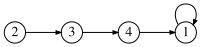

In [37]:
res = rewrite_match(rule, m) # • → • → • → •↺
to_graphviz(res; node_labels=true)

Note that C-Sets are morally regarded up to isomorphism - in particular, limits and colimits may modify the orderings of edges/vertices

In [38]:
expected = @acset Graph begin
  V = 4
  E = 4
  src = [1, 2, 3, 4]
  tgt = [2, 3, 4, 4]
end
@test is_isomorphic(expected, res)

Test Passed

We can also specify the rule via a colimit-of-representables (i.e. generators and relations) syntax. As your schema gets bigger, this becomes more and more convenient. Assigning temporary tags, e.g. e, v, eᵣ to the C-Set elements can also be helpful.

In [39]:
yG = yoneda_cache(Graph, clear=true); # compute representables

rule2 = Rule(@migration(SchRulel, SchGraph, begin
    L => @join begin
      e::E
    end
    K => @join begin
      v::V
    end
    R => @join begin
      eᵣ::E
      src(eᵣ) == tgt(eᵣ)
    end
    l => begin
      v => src(e)
    end
  end), yG);

We can also rewrite without a match (and let it pick an arbitrary match).

In [40]:
@test res == rewrite(rule, G)

Test Passed

# 2. SPO

Rules are by default DPO, but if we specify a type parameter we can change the semantics

In [41]:
rule_spo = Rule{:SPO}(l, r)  # (same data as before)

@test length(get_matches(rule_spo, G)) == 4 # there are now four matches
m = get_matches(rule_spo, G)[1]
res = rewrite_match(rule_spo, m)
to_graphviz(res)
@test is_isomorphic(res, path_graph(Graph, 3) ⊕ R)

Test Passed

Note: ⊕ and ⊗ are shorthand for (co)products 

Tip: Julia lets you easily write unicode symbols via "\" followed by a LaTeX name, then hit "Tab" to convert the symbol

# 3. SqPO

If we duplicate a vertex with an incident edge, it will duplicate the edge

In [42]:
L = Graph(1)
I = Graph(2)
R = path_graph(Graph, 2)

E,src,tgt
1,1,2


We can use automated homomorphism search to reduce the tedium of specifying data manually. In this case, there is a unique option. In general, `homomorphism` will throw an error if there is more than one homomorphism.

In [43]:
l = homomorphism(I, L)

ACSetTransformation((V = FinFunction([1, 1], 2, 1), E = FinFunction(Int64[], 0, 0)), Graph {V:2, E:0}, Graph {V:1, E:0})

There are many constraints we can put on the search, such as being monic. Here there are two monic homomorphisms (sending vertices 1 and 2 to (1,2) and (2,1)), so we add the keyword any=true to avoid throwing an error.

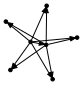

In [44]:
r = homomorphism(I, R; monic=true, any=true)

rule_sqpo = Rule{:SqPO}(l, r) # same data as before)


G = star_graph(Graph, 6) # a 5-pointed star
to_graphviz(G; prog="neato") # changing "prog" can sometimes make it look better

m = ACSetTransformation(Graph(1), G; V=[6]) # point at the center
res = rewrite_match(rule_sqpo, m)
to_graphviz(res; prog="neato")

# 4. PBPO+
   
PBPO+ requires a span just like the other kinds of rewriting.

In [45]:
L = Graph(1)
K = R = Graph(2)
l, r = homomorphism(K,L), id(K);

However, it also requires more data. The graph G that we rewrite will be typed over the L' type graph which controls how various parts of the context (not merely the matched pattern) are rewritten.

1 = root of the deep copy, 2 = children of #1, 3 = everything else

In [46]:
L′ = @acset Graph begin V=3;E=5;src=[1,2,3,3,3];tgt=[2,2,1,2,3] end
to_graphviz(L′; node_labels=true)

tl = ACSetTransformation(L,L′;V=[1])
K′ = @acset Graph begin V=5;E=9 ;
  src=[1,2,3,3,4,3,5,3,3];tgt=[2,2,3,2,5,5,5,1,4]
end
tk = ACSetTransformation(K,K′;V=[1,4])
l′ = homomorphism(K′,L′; initial=(V=[1,2,3,1,2],));

"""Given a match L → G, compute what the typing map G → L' should be"""
function get_adherence(m::ACSetTransformation)
  root, G, descendents  = only(collect(m[:V])), codom(m), Set()
  queue = [root]
  while !isempty(queue)
    nxt = pop!(queue)
    union!(descendents, outneighbors(G,nxt))
    union!(queue, outneighbors(G,nxt))
  end
  return (V = map(parts(codom(m),:V)) do v_G
    if     v_G == root       return 1
    elseif v_G ∈ descendents return 2
    else                     return 3
    end
  end,)
end

rule = PBPORule(l, r, tl, tk, l′; adherence=get_adherence);

Think of the following graph as a file system

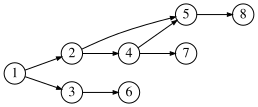

In [47]:
G = @acset Graph begin V=8; E=8;
  src=[1,1,2,2,3,4,4,5]; tgt=[2,3,4,5,6,5,7,8]
end

to_graphviz(G; node_labels=true)

Executing this rule (forcing the pattern to match at vertex 2) performs a "deepcopy" operation, copying vertex 2 and everything underneath it.

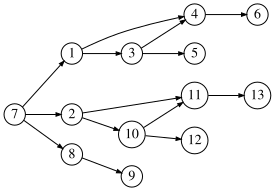

In [48]:
expected = @acset Graph begin V=13;E=14;
  src=[7,7,7,1,1,3,3,4,2,2,10,10,11,8]; tgt=[1,2,8,3,4,5,4,6,10,11,12,11,13,9]
end

@test is_isomorphic(expected, rewrite(rule, G; initial=(V=[2],)))

to_graphviz(expected; node_labels=true)

# 5. Generalizing Graphs
   
Any data structure which implements the required functions we need can, in principle, be used for rewriting. Importantly this includes pushout_complement, pushout, and homomorphism search. These are all implemented generically for any C-Set schema (allowing us to rewrite Petri nets, Semisimplicial sets, etc.)

Here we'll do rewriting in graphs sliced over •⇆•, which is isomorphic to the category of (whole-grain) Petri nets, with States and Transitions.

In [49]:
function graph_slice(s::Slice)
  h = s.slice
  V, E = collect.([h[:V], h[:E]])
  g = dom(h)
  (S, T), (I, O) = [[findall(==(i), X) for i in 1:2] for X in [V, E]]
  nS, nT, nI, nO = length.([S, T, I, O])
  findS, findT = [x -> findfirst(==(x), X) for X in [S, T]]
  to_graphviz(@acset AlgebraicPetri.PetriNet begin
    S = nS; T = nT; I = nI; O = nO
    is = findS.(g[I, :src])
    it = findT.(g[I, :tgt])
    ot = findT.(g[O, :src])
    os = findS.(g[O, :tgt])
  end)
end;

This is the graph we are slicing over.

In [50]:
two = @acset Graph begin
  V = 2; E = 2; src = [1, 2]; tgt = [2, 1]
end

to_graphviz(two)

Define a rule which deletes a [T] -> S edge. Start with the pattern, L.

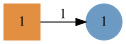

In [51]:
L_ = path_graph(Graph, 2)
L = Slice(ACSetTransformation(L_, two, V=[2, 1], E=[2])) # [T] ⟶ (S)
graph_slice(L)

Then define I and R

In [52]:
I_ = Graph(1)
I = Slice(ACSetTransformation(I_, two, V=[2])) # [T]
R_ = Graph(2)
R = Slice(ACSetTransformation(R_, two, V=[2, 1])) # [T]  (S)

Slice{StructTightACSetTransformation{TypeLevelBasicSchema{Symbol, Tuple{:V, :E}, Tuple{(:src, :E, :V), (:tgt, :E, :V)}, Tuple{}, Tuple{}, Tuple{}}, @NamedTuple{V::Catlab.CategoricalAlgebra.FinSets.FinDomFunctionVector{Int64, Vector{Int64}, Catlab.CategoricalAlgebra.FinSets.FinSetInt}, E::Catlab.CategoricalAlgebra.FinSets.FinDomFunctionVector{Int64, Vector{Int64}, Catlab.CategoricalAlgebra.FinSets.FinSetInt}}, Graph, Graph}}(ACSetTransformation((V = FinFunction([2, 1], 2, 2), E = FinFunction(Int64[], 0, 2)), Graph {V:2, E:0}, Graph {V:2, E:2}))

Using homomorphism search in the slice category

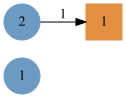

In [53]:
rule = Rule(homomorphism(I, L), homomorphism(I, R))

G_ = path_graph(Graph, 3)
G = Slice(ACSetTransformation(G_, two, V=[1, 2, 1], E=[1, 2])) # (S) ⟶ [T] ⟶ (S)
graph_slice(G)

res = rewrite(rule, G) # (S) ⟶ [T]  (S)
graph_slice(res)

While the vast majority of functionality is focused on ACSets at the present moment, but there is nothing in principle which limits this.

# 6. Application conditions
   
We can construct commutative diagrams with certain edges left unspecified or marked with ∀ or ∃. If only one edge is left free, we can treat the diagram as a boolean function which tests whether the morphism makes the specified paths commute (or not commute). This generalizes positive/negative application conditions and lifting conditions, but because those are most common there are constructors AppCond and LiftCond to make these directly.

Every vertex with a loop also has a map to the vertex marked by the bottom map.

In [54]:
t = terminal(Graph) |> apex
looparr = @acset_colim yG begin
  (e1, e2)::E
  src(e1) == tgt(e1)
  src(e1) == src(e2)
end

v = homomorphism(t, looparr)
loop_csp = @acset Graph begin
  V = 3; E = 4; src = [1, 3, 1, 3]; tgt = [1, 3, 2, 2]
end
b = homomorphism(looparr, loop_csp; initial=(V=[2,1],))
constr = LiftCond(v, b)

@test !apply_constraint(constr, homomorphism(t, loop_csp; initial=(V=[1],)))
@test apply_constraint(constr, b)

Test Passed

We can combining constraints with logical combinators.

match vertex iff it has 2 or 3 self loops

In [55]:
one, two, three, four, five = [@acset(Graph, begin
  V = 1; E = n; src = 1; tgt = 1
end) for n in 1:5]

c2 = PAC(homomorphism(Graph(1), two); monic=true)         # PAC
c3 = NAC(homomorphism(Graph(1), four); monic=true) # NAC
constr = c2 ⊗ c3 # logical conjunction: 2 ≤ |E| < 4

rule = Rule(id(Graph(1)), id(Graph(1)); ac=[constr])

G = two ⊕ three ⊕ two ⊕ four ⊕ five ⊕ one

@test length(get_matches(rule, G)) == 3

Test Passed

# 7. Attribute variables
   
Normally ACSet morphisms must match attribute values exactly, i.e. a weighted graph edge of 8.3 can only be mapped to another edge weighted at 8.3. This becomes very restricted, especially when we want to do some simple computations with attribute values (e.g. when merging two edges, add their values together)

A recent extension of ACSets makes this possible - each attribute type comes equipped with a finite set of "variables" which can be mapped to any concrete value (or another variable).

In [56]:
yWG = yoneda_cache(WeightedGraph{Int}; clear=true);
L = @acset_colim yWG begin
  (e1, e2)::E
  src(e1) == src(e2)
  tgt(e1) == tgt(e2)
end
I = WeightedGraph{Int}(2)
R = @acset WeightedGraph{Int} begin
  V = 2; E = 1; Weight = 1
  src = [1]; tgt = [2]; weight = [AttrVar(1)]
end

l = homomorphism(I, L; initial=(V=1:2,))
r = homomorphism(I, R; initial=(V=1:2,))
rule = Rule(l, r; monic=[:E], expr=Dict(:Weight => [((w₁,w₂),) -> w₁ + w₂]))

G = @acset WeightedGraph{Int} begin
  V = 1; E = 3; src = 1; tgt = 1; weight = [10, 20, 100]
end

m = homomorphism(L, G; initial=(E=1:2,))
@test rewrite_match(rule, m) == @acset WeightedGraph{Int} begin
  V = 1; E = 2; src = [1]; tgt = [1]; weight = [30, 100]
end

Test Passed

# 8. Graph processes

A sequence of rewrite applications can be given a poset structure where α ≤ β means that the rule application α needed to occur before β. This is computed via analyzing the colimit of all the partial maps induced by the rewrites.

In [57]:
using AlgebraicRewriting.Processes: RWStep, find_deps

G0, G1, G2, G3 = Graph.([0, 1, 2, 3])

4-element Vector{Graph}:
 Graph:
  V = 1:0
  E = 1:0
  src : E → V = Int64[]
  tgt : E → V = Int64[]
 Graph:
  V = 1:1
  E = 1:0
  src : E → V = Int64[]
  tgt : E → V = Int64[]
 Graph:
  V = 1:2
  E = 1:0
  src : E → V = Int64[]
  tgt : E → V = Int64[]
 Graph:
  V = 1:3
  E = 1:0
  src : E → V = Int64[]
  tgt : E → V = Int64[]

Delete a node

In [58]:
Rule1 = Span(create(G1), id(G0));

Merge two nodes

In [59]:
Rule2 = Span(id(G2), homomorphism(G2, G1));

Add a node

In [60]:
Rule3 = Span(id(G0), create(G1))

R1, R2, R3 = [Rule(l, r) for (l, r) in [Rule1, Rule2, Rule3]]

3-element Vector{Rule{:DPO}}:
 Rule{:DPO}(ACSetTransformation((V = FinFunction(Int64[], 0, 1), E = FinFunction(Int64[], 0, 0)), Graph {V:0, E:0}, Graph {V:1, E:0}), ACSetTransformation((V = id(FinSet(0)), E = id(FinSet(0))), Graph {V:0, E:0}, Graph {V:0, E:0}), Constraint[], Symbol[], Dict{Symbol, Dict{Int64, Union{Nothing, Function}}}())
 Rule{:DPO}(ACSetTransformation((V = id(FinSet(2)), E = id(FinSet(0))), Graph {V:2, E:0}, Graph {V:2, E:0}), ACSetTransformation((V = FinFunction([1, 1], 2, 1), E = FinFunction(Int64[], 0, 0)), Graph {V:2, E:0}, Graph {V:1, E:0}), Constraint[], Symbol[], Dict{Symbol, Dict{Int64, Union{Nothing, Function}}}())
 Rule{:DPO}(ACSetTransformation((V = id(FinSet(0)), E = id(FinSet(0))), Graph {V:0, E:0}, Graph {V:0, E:0}), ACSetTransformation((V = FinFunction(Int64[], 0, 1), E = FinFunction(Int64[], 0, 0)), Graph {V:0, E:0}, Graph {V:1, E:0}), Constraint[], Symbol[], Dict{Symbol, Dict{Int64, Union{Nothing, Function}}}())

# 9. Trajectory
    
Step 1: add node 3 to G2

In [61]:
M1 = create(G2)
CM1 = ACSetTransformation(G1, G3; V=[3])
Pmap1 = Span(id(G2), ACSetTransformation(G2, G3; V=[1, 2]))
RS1 = RWStep(Rule3, Pmap1, M1, CM1);

Step 2: merge node 2 and 3 to yield a G2

In [62]:
M2 = ACSetTransformation(G2, G3; V=[2, 3])
CM2 = ACSetTransformation(G1, G2; V=[2])
Pmap2 = Span(id(G3), ACSetTransformation(G3, G2; V=[1, 2, 2]))
RS2 = RWStep(Rule2, Pmap2, M2, CM2);

Step 3: delete vertex 1

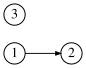

In [63]:
M3 = ACSetTransformation(G1, G2; V=[1])
CM3 = create(G1)
Pmap3 = Span(ACSetTransformation(G1, G2; V=[2]), id(G1))
RS3 = RWStep(Rule1, Pmap3, M3, CM3);


steps = [RS1, RS2, RS3];

g = find_deps(steps)
to_graphviz(g; node_labels=true)

Confirm this what we expect



In [64]:
expected = @acset Graph begin V = 3; E = 1; src = 1; tgt = 2 end
@test expected == g

Test Passed

Interface that just uses rules and match morphisms: The matches needed to be updated to reflect the particular isomorph that DPO rewriting produces when applying the rule.

In [65]:
σ₂ = ACSetTransformation(G2, G2; V=[2, 1])
σ₃ = ACSetTransformation(G3, G3; V=[3, 1, 2])

g′ = find_deps([R3 => M1, R2 => M2 ⋅ σ₃, R1 => M3 ⋅ σ₂])
@test g′ == g

Test Passed